In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import plotly.graph_objects as go
import plotly.io as pio

from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table

from scipy.optimize import curve_fit

from darksirenpop.utilities.utils import make_nice_plots
from darksirenpop.utilities.default_globals import *

make_nice_plots()


# Calculate Quaia bolometric luminosities

In [2]:
# Load data

with fits.open(QUAIA_FITS_PATH) as hdul:
   hdul.verify('fix')
   data = hdul[1].data
   tab = Table(hdul[1].data)
   quaia_Gmag = data['phot_rp_mean_mag']
   quaia_redshift = data['redshift_quaia']
   quaia_lumdist = COSMO.luminosity_distance(quaia_redshift)
quaia_lumdist_cm = quaia_lumdist.to(u.cm).value


In [3]:
# Calculate flux in electrons per second

ZP = 24.7479
C_NU = 3.298815E-33

f_elecpersec = 10**(-(quaia_Gmag - ZP) / 2.5)
log10_f_ergscm2Hz = np.log10(f_elecpersec) + np.log10(C_NU) + 3

# Calculate shape of SED in the frequency range we are interested in
# Observed frequency: 10^14.588 Hz
# Maximum emitted frequency = (1+z_max)*observed_frequency = 4*observed frequency
log_nu_max = np.log10(4*(10**14.588))
print('The log of the maximum emitted frequency is ',np.round(log_nu_max,3))
### x and y (in the following lines) have been obtained with webplotdigitizer from Figure 11 of
### https://iopscience.iop.org/article/10.1086/506525/pdf

x = [14.586, 15.191]
y = [45.315, 45.692]
slope = (y[1] - y[0]) / (x[1] - x[0])
print('The spectral index of the SED in the frequency range we are interested is ', np.round(slope, 3))


log10_bandlum = 14.588 + log10_f_ergscm2Hz + np.log10(4 * np.pi) + 2 * np.log10(quaia_lumdist_cm) + (-1 * slope) * np.log10(1 + quaia_redshift)  # Band luminosity
log10_bollum = log10_bandlum + np.log10(11.004)  # Bolometric luminosity

### Save Quaia with added column bolometric luminosity ###
tab['log10_bollum'] = log10_bollum
# tab.write('/home/lucas/Documents/PhD/agn_data/quaia_G20.5_withbollum.fits', overwrite=True)  # Don't feel like coding the conversion to .csv, I already have the file


The log of the maximum emitted frequency is  15.19
The spectral index of the SED in the frequency range we are interested is  0.623


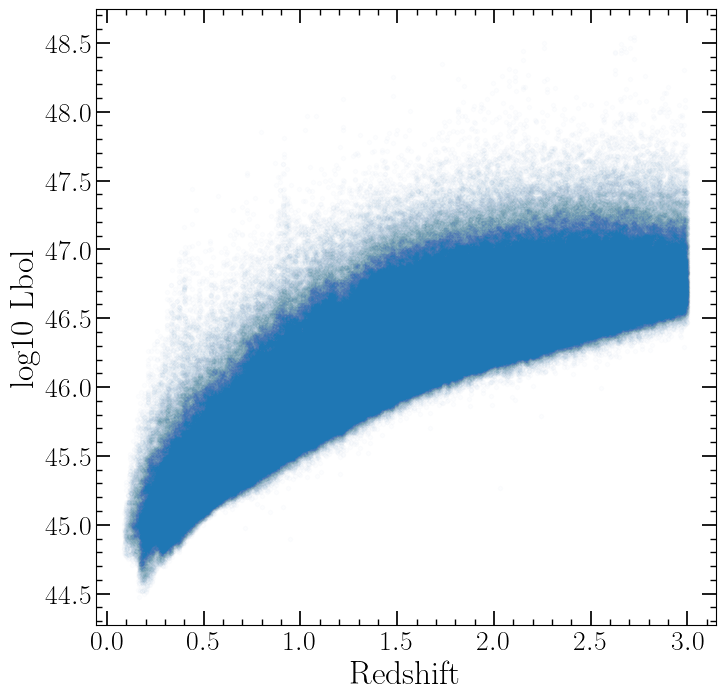

In [4]:
# Plot the luminosities obtained from Quaia

plt.figure(figsize=(8,8))
plt.scatter(quaia_redshift[quaia_redshift < 3], log10_bollum[quaia_redshift < 3], marker='.', alpha=0.01)
plt.xlabel('Redshift')
plt.ylabel('log10 Lbol')
plt.show()


# Exploratory data analysis of the Wu&Shen sample of SDSS DR16Q

In [5]:
hdul = fits.open(DR16Q_PATH)
print( hdul.info() )

hdr1 = hdul[1].header
hdr2 = hdul[2].header

print()
print(hdr1.keys)
print()
print(hdr2.keys)


Filename: /home/lucas/Documents/PhD/agn_data/dr16q_prop_May01_2024.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    238   750414R x 115C   [18A, K, K, K, D, D, 20A, 10A, D, 12A, D, D, D, D, D, 5D, 5D, 2D, 3D, 3D, D, D, 3D, 3D, D, D, D, D, D, D, D, D, D, D, D, D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, D, D, D, D, D, D, D, D, D, D, D, D, 8D, 8D, D]   
  2                1 BinTableHDU    188   750414R x 90C   [5D, 5D, 5D, E, D, D, D, D, D, D, D, D, J, J, J, 5E, 5D, 5E, 5D, 5E, D, D, I, D, D, D, D, I, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, I, E, E, E, E, E, E, E, E, E, I, I, D, D, D, D, D, D, J, D, D, D, J, D, D, D, J, D, 21A, D, D, E, E, D, K, D, D, E, E, E,

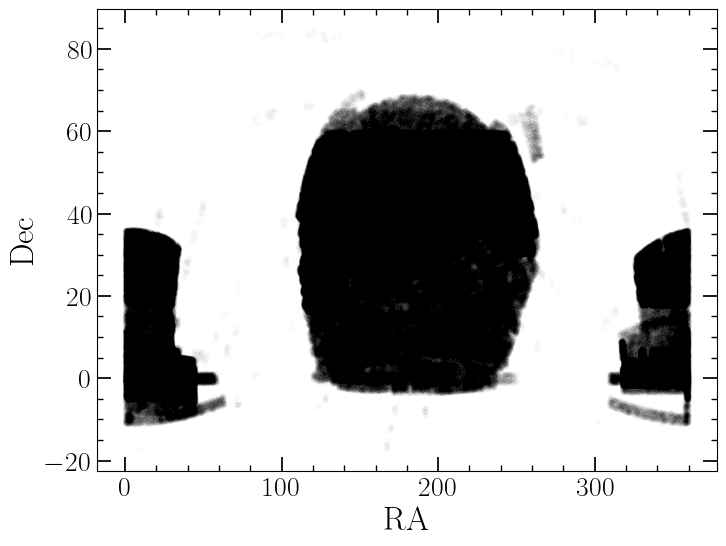

In [7]:
# Check survey footprint

ra_sdss = hdul[1].data['RA']
dec_sdss = hdul[1].data['DEC']

plt.figure(figsize=(8,6))
plt.scatter(ra_sdss, dec_sdss, marker='.', alpha=0.01, color='black')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.show()


3089


/tmp/ipykernel_1735525/2431551865.py:6: RuntimeWarning: divide by zero encountered in divide
  mask = (z_sys > 0) & (z_sys_err > 0) & (z_sys_err < 0.02) & (z_sys_err / z_sys < 0.01)  # To better visualise the data


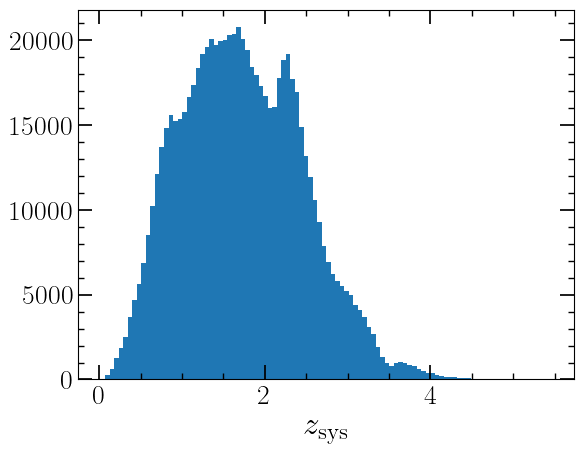

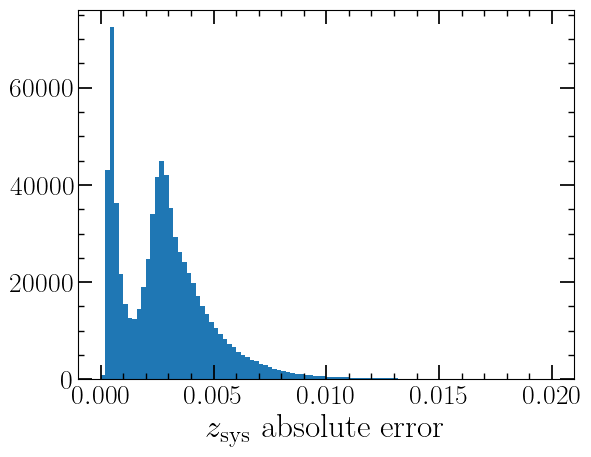

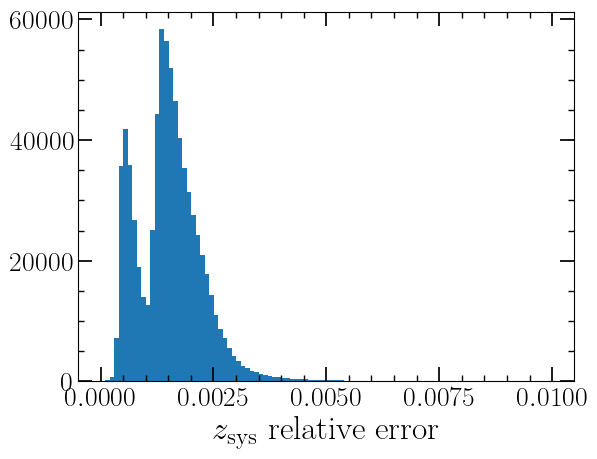

In [ ]:
# z_sys are the improved redshifts of Wu&Shen

z_sys = hdul[1].data['Z_SYS']
z_sys_err = hdul[1].data['Z_SYS_ERR']

mask = (z_sys > 0) & (z_sys_err > 0) & (z_sys_err < 0.02) & (z_sys_err / z_sys < 0.01)  # To better visualise the data
print(np.sum(~mask))

plt.hist(z_sys[mask], bins=100)
plt.xlabel(r'$z_{\rm sys}$')
plt.show()

plt.hist(z_sys_err[mask], bins=100)
plt.xlabel(r'$z_{\rm sys}$ absolute error')
plt.show()

plt.hist(z_sys_err[mask] / z_sys[mask], bins=100)
plt.xlabel(r'$z_{\rm sys}$ relative error')
plt.show()


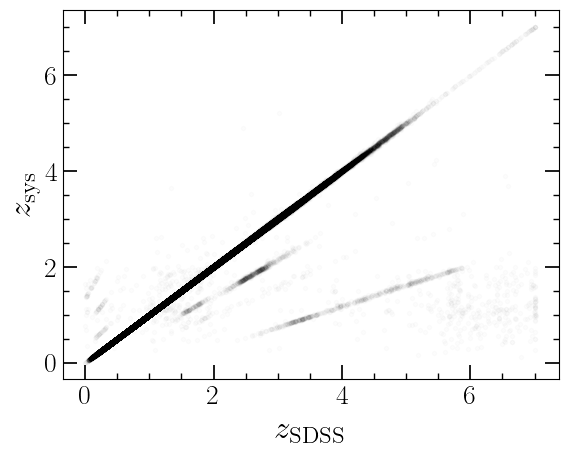

24938 sources out of 750401 have difference larger than 0.01


In [ ]:
# Compare Wu&Shen with original SDSS redshifts

z_sdss = hdul[1].data['Z_DR16Q']
mask = (z_sdss > 0) & (z_sys > 0)
plt.scatter(z_sdss[mask], z_sys[mask], marker = '.', color='black', alpha=0.01)
plt.xlabel(r'$z_{\rm SDSS}$')
plt.ylabel(r'$z_{\rm sys}$')
plt.show()

delta = 0.01
nonzero_diff = abs(z_sdss[mask] - z_sys[mask]) > delta
print(f'{np.sum(nonzero_diff)} sources out of {len(nonzero_diff)} have difference larger than {delta}')


# Load in Quaia ($z \leq 3$) and crossmatch it with SDSS

In [ ]:
df = pd.read_csv(QUAIA_PATH)
cols = ["redshift_quaia", "redshift_quaia_err", "ra", "dec", "b", "log10_bollum", "loglbol_corr"]
quaia = df[cols]

z_quaia = quaia['redshift_quaia']
z_err_quaia = quaia['redshift_quaia_err']
ra_quaia = quaia['ra'].to_numpy()
dec_quaia = quaia['dec'].to_numpy()
print(len(z_quaia))


1259043


283253 sources found within 2.0 arcsec of each other. Maximum angular separation: 1.93 arcsec


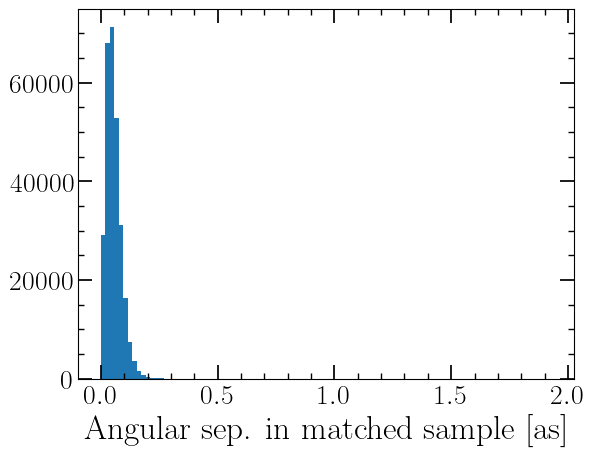

In [ ]:
# Make angular crossmatch between SDSS and Quaia

sdss_skycoord = SkyCoord(ra=ra_sdss * u.degree, dec=dec_sdss * u.degree)
quaia_skycoord = SkyCoord(ra=ra_quaia *  u.degree, dec=dec_quaia * u.degree)

max_sep = 2.0 * u.arcsec

idx_sdss, idx_quaia, d2d, _ = quaia_skycoord.search_around_sky(sdss_skycoord, max_sep)
sep_constraint = d2d < max_sep
print(f'{np.sum(sep_constraint)} sources found within {max_sep} of each other. Maximum angular separation: {np.max(d2d.to(u.arcsec)):.2f}')

plt.hist(d2d[sep_constraint].to(u.arcsec).value, bins=100)
plt.xlabel('Angular sep. in matched sample [as]')
plt.show()


In [ ]:
# Get crossmatch of catalogs as new catalogs

sdss_match = hdul[1].data[idx_sdss]
quaia_match = quaia.iloc[idx_quaia]
print(len(sdss_match), len(quaia_match))


283253 283253


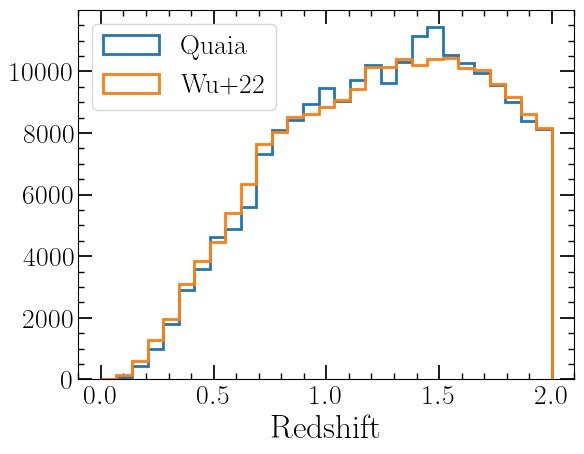

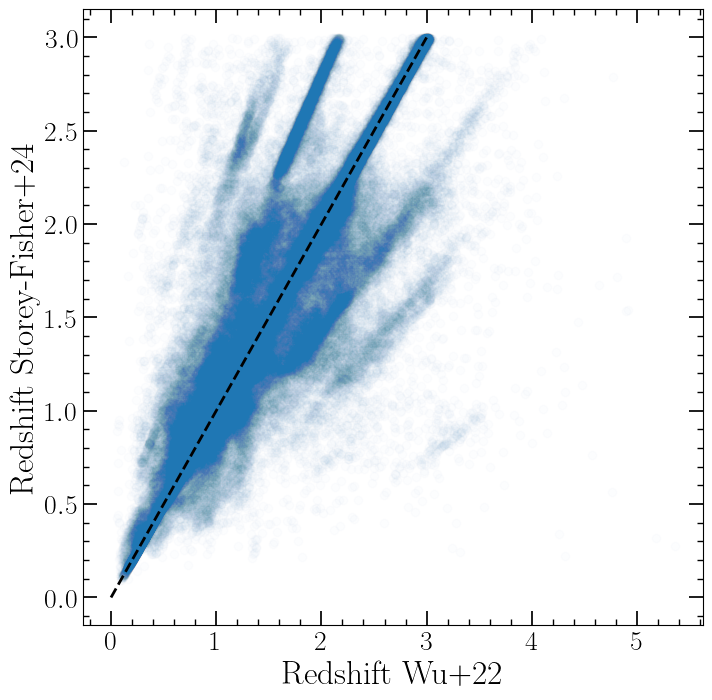

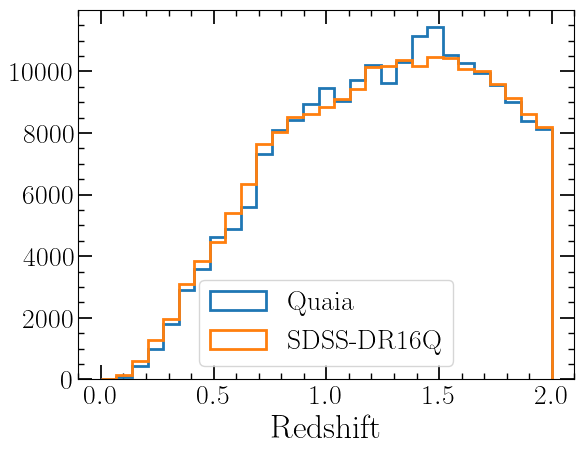

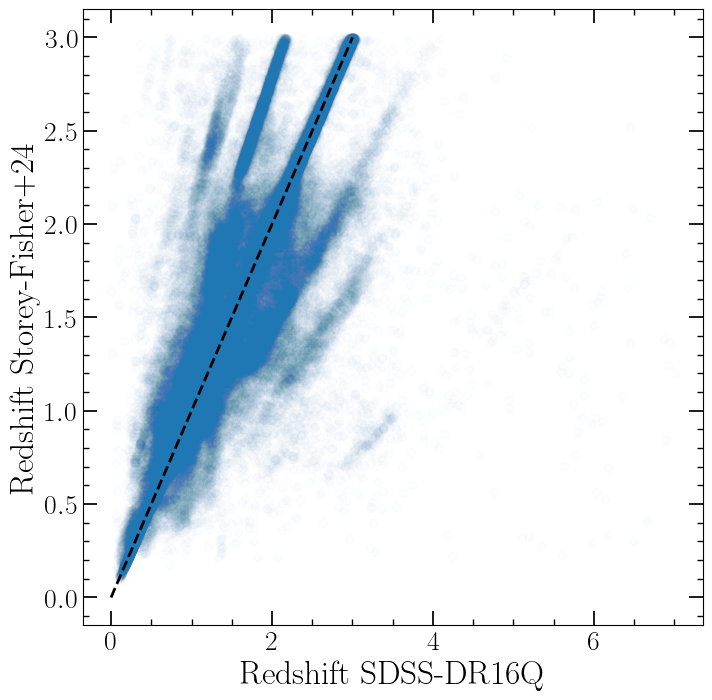

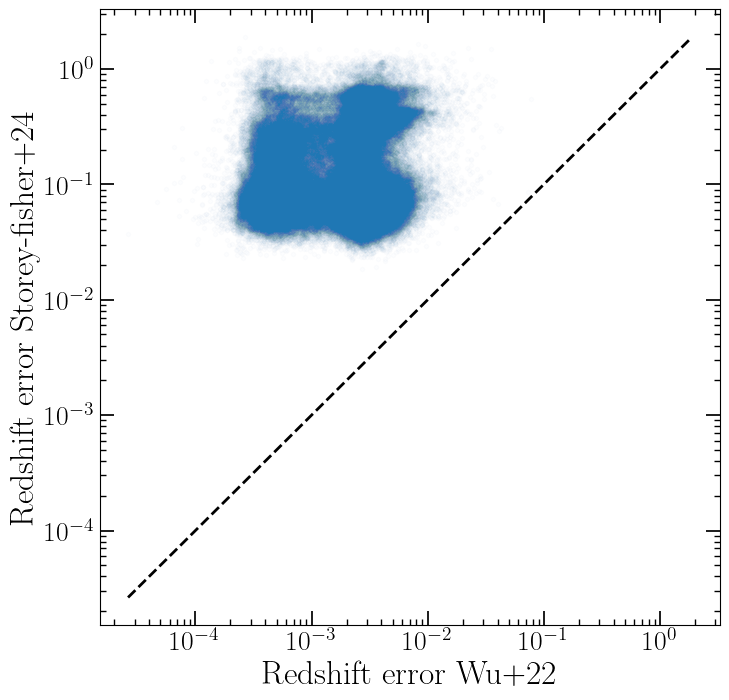

In [ ]:
# Compare the Wu&Shen data vs the Quaia data vs the SDSS data, all for the same sources

for ztype, label in zip(['Z_SYS', 'Z_DR16Q'], ['Wu+22', 'SDSS-DR16Q']):
    z_sys_match = sdss_match[ztype]
    z_sys_err_match = sdss_match['Z_SYS_ERR']

    z_quaia_match = quaia_match['redshift_quaia'].to_numpy()
    z_err_quaia_match = quaia_match['redshift_quaia_err'].to_numpy()

    mask = (z_sys_match > 0) & (z_sys_err_match > 0)

    edges = np.linspace(0, 2, 30)
    dens = False
    plt.figure()
    plt.hist(z_quaia_match[mask], histtype='step', linewidth=2, bins=edges, density=dens, label='Quaia')
    plt.hist(z_sys_match[mask], histtype='step', linewidth=2, bins=edges, density=dens, label=f'{label}')
    plt.xlabel('Redshift')
    plt.legend()
    plt.show()

    zz = np.linspace(0, 3, 100)
    plt.figure(figsize=(8, 8))
    plt.scatter(z_sys_match[mask], z_quaia_match[mask], alpha=0.01)
    plt.plot(zz, zz, color='black', linewidth=2, linestyle='dashed')
    plt.xlabel(f'Redshift {label}')
    plt.ylabel('Redshift Storey-Fisher+24')
    plt.show()


mask = (sdss_match['Z_SYS'] > 0) & (z_sys_err_match > 0)

ss = np.linspace(np.min(z_sys_err_match[mask]), np.max(z_err_quaia_match[mask]), 100)
plt.figure(figsize=(8, 8))
plt.scatter(z_sys_err_match[mask], z_err_quaia_match[mask], marker='.', alpha=0.01)
plt.plot(ss, ss, color='black', linewidth=2, linestyle='dashed')
plt.loglog()
plt.xlabel('Redshift error Wu+22')
plt.ylabel('Redshift error Storey-fisher+24')
plt.show()


# Compare bolometric luminosities with Wu&Shen, correct for difference

In [ ]:
def linear(x, a, b):
    return a * x + b


In [ ]:
logLbol_sdss = sdss_match['LOGLBOL']
logLbol_err_sdss = sdss_match['LOGLBOL_ERR']
mask = (logLbol_sdss > 0.) & (logLbol_err_sdss > 0.)
print(np.sum(mask), np.sum(~mask))

logLbol_quaia_uncorrected = quaia_match['log10_bollum'].to_numpy()
diff_old = (logLbol_sdss - logLbol_quaia_uncorrected)[mask]
print(f'Median: {np.median(diff_old)}, Mean: {np.mean(diff_old)}, Standard deviation: {np.std(diff_old)}')


281785 1468
Median: -0.09467453200389997, Mean: -0.10903779441230929, Standard deviation: 0.20355761746025927


[-0.04297071 -0.04156193] [0.00058286 0.00099094]
[-0.04846116  2.13256465] [0.00082362 0.03809883]


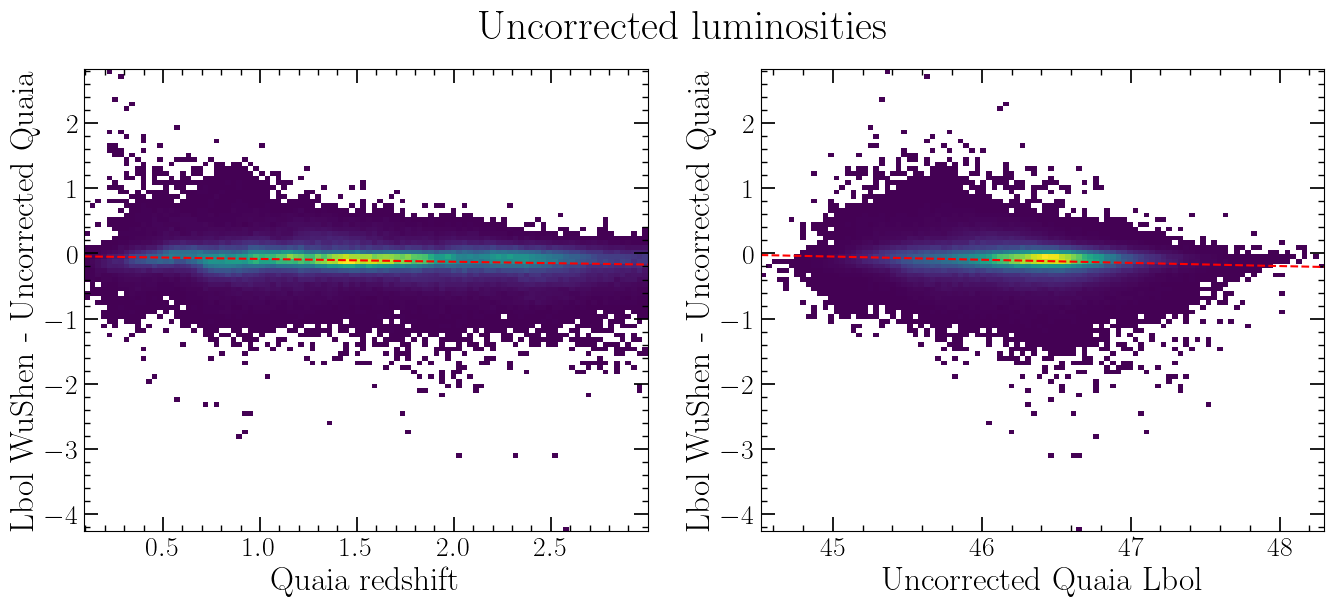

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Uncorrected luminosities', fontsize=30)

xdat = quaia_match['redshift_quaia'][mask]
ydat = diff_old
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax1.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax1.hist2d(
    xdat,
    diff_old,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax1.set_ylabel('Lbol WuShen - Uncorrected Quaia')
ax1.set_xlabel('Quaia redshift')

xdat = logLbol_quaia_uncorrected[mask]
ydat = diff_old
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax2.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax2.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax2.set_ylabel('Lbol WuShen - Uncorrected Quaia')
ax2.set_xlabel('Uncorrected Quaia Lbol')
plt.show()


# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# fig.suptitle('Corrected luminosities', fontsize=30)

# xdat = quaia_match['redshift_quaia'][mask]
# ydat = diff
# param, pcov = curve_fit(linear, xdat, ydat)
# print(param, np.sqrt(np.diag(pcov)))
# xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
# ax1.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

# ax1.hist2d(
#     xdat,
#     ydat,
#     bins=100,
#     cmin=1,
#     cmap='viridis'
# )
# ax1.set_ylabel('Lbol WuShen - Corrected Quaia')
# ax1.set_xlabel('Quaia redshift')

# xdat = logLbol_quaia_uncorrected[mask]
# ydat = diff
# param, pcov = curve_fit(linear, xdat, ydat)
# print(param, np.sqrt(np.diag(pcov)))
# xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
# ax2.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

# ax2.hist2d(
#     xdat,
#     ydat,
#     bins=100,
#     cmin=1,
#     cmap='viridis'
# )
# ax2.set_ylabel('Lbol WuShen - Corrected Quaia')
# ax2.set_xlabel('Uncorrected Quaia Lbol')
# plt.show()


# plt.figure()
# plt.hist(diff, bins=100, density=True, label='Corrected', alpha=0.5)
# plt.hist(diff_old, bins=100, density=True, label='Original', alpha=0.5)
# plt.xlabel(r'$\Delta \log_{10} L_{\rm bol}$ (WuShen vs Quaia)')
# plt.ylabel('Probability density')
# plt.legend()
# plt.show()

# ll = np.linspace(44, 49, 100)
# plt.figure(figsize=(6,6))
# plt.scatter(logLbol_sdss[mask], logLbol_quaia[mask], marker='.', alpha=0.1)
# plt.plot(ll, ll, color='black', linestyle='dashed', linewidth=2)
# plt.xlabel('Lbol SDSS')
# plt.ylabel('Lbol Quaia')
# plt.show()


# Correct by fitting plane through point cloud

f(x,y) = -0.02051 + -0.04271 x + -0.000464 y


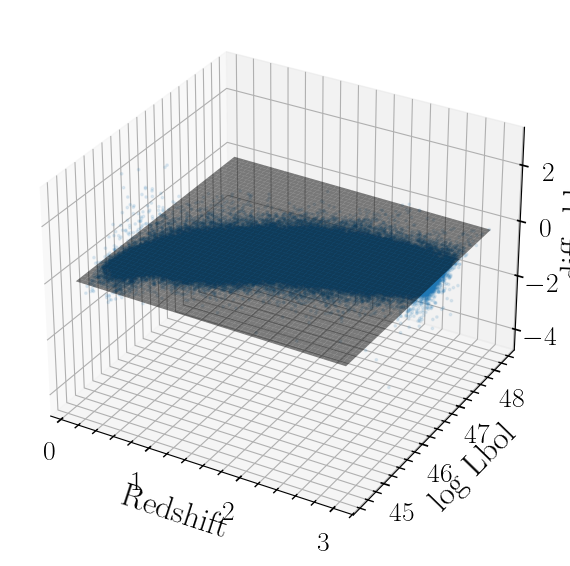

In [ ]:
x = np.asarray(quaia_match['redshift_quaia'])[mask]
y = np.asarray(logLbol_quaia_uncorrected)[mask]
z = np.asarray(diff_old)

# Remove NaNs/infs
good = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x_fit = x[good]
y_fit = y[good]
z_fit = z[good]

# Design matrix: constant, x, y
A = np.column_stack([
    np.ones(len(x_fit)),
    x_fit,
    y_fit
])

# Fit z = a + b*x + c*y
coeff, residuals, rank, s = np.linalg.lstsq(A, z_fit, rcond=None)

a, b, c = coeff

print(f"f(x,y) = {a:.4g} + {b:.4g} x + {c:.4g} y")


fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Data
ax.scatter(
    x_fit, y_fit, z_fit,
    s=3,
    alpha=0.1
)

# Plane
xx = np.linspace(x_fit.min(), x_fit.max(), 50)
yy = np.linspace(y_fit.min(), y_fit.max(), 50)
XX, YY = np.meshgrid(xx, yy)

ZZ = a + b*XX + c*YY

ax.plot_surface(
    XX, YY, ZZ,
    alpha=0.5,
    color='black'
)

ax.set_xlabel('Redshift')
ax.set_ylabel('log Lbol')
ax.set_zlabel('diff_old')

plt.show()


# Render plane fit through point cloud in browser (optional)

In [ ]:
# pio.renderers.default = "browser"

# # Data
# x = np.asarray(quaia_match['redshift_quaia'])[mask]
# y = np.asarray(logLbol_quaia_uncorrected)[mask]
# z = np.asarray(diff_old)

# # Remove NaNs / infs
# good = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

# x_fit = x[good]
# y_fit = y[good]
# z_fit = z[good]

# # Fit plane: z = a + b*x + c*y
# A = np.column_stack([
#     np.ones(len(x_fit)),
#     x_fit,
#     y_fit
# ])

# a, b, c = np.linalg.lstsq(A, z_fit, rcond=None)[0]

# print(f"Plane: z = {a:.4f} + {b:.4f} x + {c:.4f} y")

# # Grid for plane
# xx = np.linspace(x_fit.min(), x_fit.max(), 50)
# yy = np.linspace(y_fit.min(), y_fit.max(), 50)
# XX, YY = np.meshgrid(xx, yy)

# ZZ = a + b * XX + c * YY

# # Interactive figure
# fig = go.Figure()

# # Data
# fig.add_trace(go.Scatter3d(
#     x=x_fit,
#     y=y_fit,
#     z=z_fit,
#     mode='markers',
#     name='Data',
#     marker=dict(
#         size=3,
#         color='blue',
#         opacity=0.05
#     )
# ))

# # Fitted plane
# fig.add_trace(go.Surface(
#     x=XX,
#     y=YY,
#     z=ZZ,
#     name='Best-fit plane',
#     opacity=0.5,
#     showscale=False
# ))

# fig.update_layout(
#     scene=dict(
#         xaxis_title='Redshift',
#         yaxis_title='log Lbol',
#         zaxis_title='diff_old'
#     ),
#     title='Linear plane fit to diff_old'
# )

# fig.show()


# Apply correction and check result

In [ ]:
xdat = np.asarray(quaia_match['redshift_quaia'])[mask]
ydat = np.asarray(logLbol_quaia_uncorrected)[mask]
corrected_Lbol_quaia = ydat + a + b*xdat + c*ydat
new_diff = logLbol_sdss[mask] - corrected_Lbol_quaia
print('Median, mean, std [dex]:', np.median(new_diff), np.mean(new_diff), np.std(new_diff))

Median, mean, std [dex]: 0.013657162336471629 -1.36518209677775e-16 0.2016223759566927


[-4.23516777e-11  6.85106416e-11] [9.19309528e-05 1.48088753e-04]
[-1.01048858e-09  4.68718960e-08] [0.00048836 0.02259102]


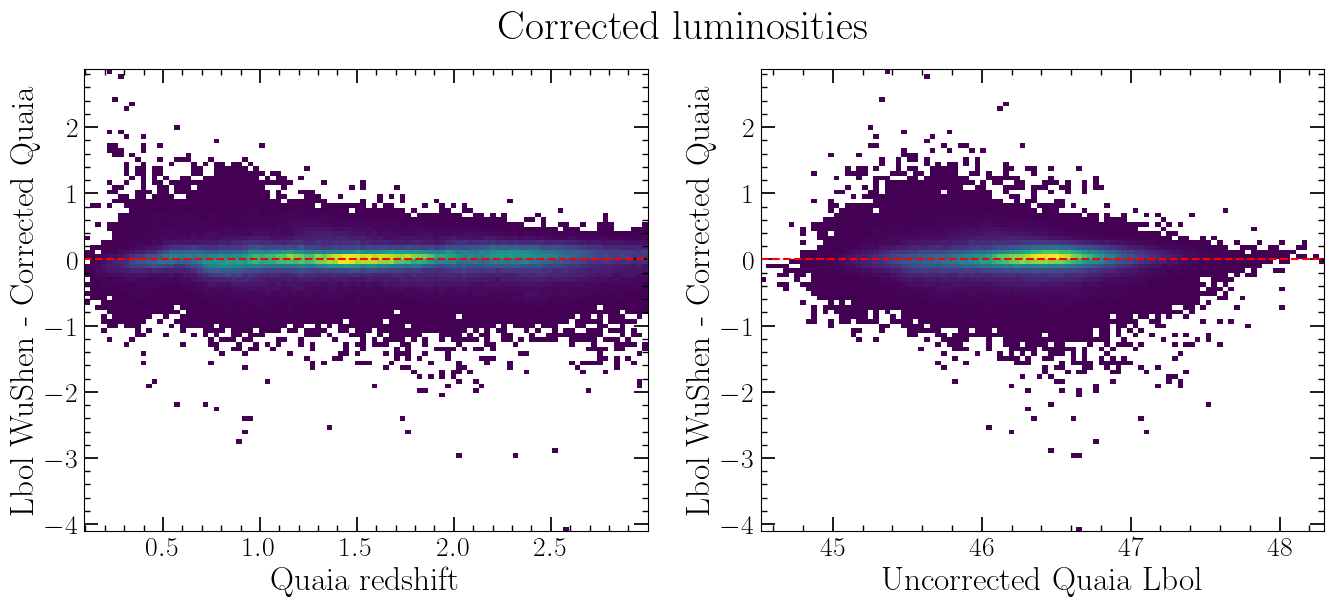

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corrected luminosities', fontsize=30)

xdat = quaia_match['redshift_quaia'][mask]
ydat = new_diff
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax1.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax1.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax1.set_ylabel('Lbol WuShen - Corrected Quaia')
ax1.set_xlabel('Quaia redshift')

xdat = logLbol_quaia_uncorrected[mask]
ydat = new_diff
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax2.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax2.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax2.set_ylabel('Lbol WuShen - Corrected Quaia')
ax2.set_xlabel('Uncorrected Quaia Lbol')
plt.show()


# Apply correction to full dataset and store

In [ ]:
df = pd.read_csv(QUAIA_PATH)
xdat = np.asarray(df['redshift_quaia'])
ydat = np.asarray(df['log10_bollum'])
df["loglbol_corr"] = ydat + a + b*xdat + c*ydat

# Save
# df.to_csv(QUAIA_PATH, index=False)


In [ ]:
# # Comparison of smooth correction method vs binned correction method (V25)

# plt.figure(figsize=(10,10))
# plt.scatter(xdat, df["loglbol_corr"], marker='.', alpha=0.1)
# plt.scatter(xdat, df['loglbol_corr_V25'], marker='.', alpha=0.1, color='red')
# plt.show()
